In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import pickle
import mygene
from pathlib import Path
from scipy.stats import hypergeom
from statsmodels.stats.multitest import multipletests
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Inital setting for plot size
from matplotlib import rcParams

FIGSIZE = (4, 4)
rcParams["figure.figsize"] = FIGSIZE

import sys
sys.path.append('/mnt/research/FishEvoDevoGeno/Hao/icepop/icepop')
from data import HomologyData
from convert_score_across_species import CrossSpeciesScoreConverter

In [2]:
adata = sc.read('../data/sc_data/mouse_colon__metaq__corrected_ctcomb__spec_calc.h5ad')

In [3]:
indir = '../results/2026-01-08__asd_colon__ctcomb__mc-75__perm-1000'

trait = 'asd'
mc_asso = f'{indir}/metacell__trait-{trait}.csv'
ct_asso = f'{indir}/celltype__trait-{trait}.csv'

mc_df = pd.read_csv(mc_asso, header=0, index_col=None)
mc_df = mc_df.set_index('metacell')
ct_df = pd.read_csv(ct_asso, header=0, index_col=None)
ct_df = ct_df.set_index('celltype')

# add mc count in each ct
min_purity = 0.2
freq_df = pd.crosstab(adata.obs['cell_type'], adata.obs['SEACell'])
freq_df = freq_df.div(freq_df.sum(0))
ct2meta = {ct: np.asarray(row[row >= min_purity].index) for ct, row in freq_df.iterrows()}
ct_df['n_mc'] = [len(ct2meta[ct]) for ct in ct_df.index]

In [4]:
def capitalize_first_if_not_all_caps(s):
    if s.isupper():
        return s
    return s[0].upper() + s[1:]

def plot_tsne(adata, col, cmap='Reds', alpha=1, vmin=None, vmax=None, title=None, size=20, outfile=None, cbar=None):
    # Determine if we use custom scaling
    use_limits = isinstance(vmin, (float, int)) and isinstance(vmax, (float, int))
    
    # Generate the plot
    ax = sc.pl.tsne(
        adata,
        color=col,
        show=False,
        size=size,
        cmap=cmap,
        alpha=alpha,
        vmin=vmin if use_limits else None,
        vmax=vmax if use_limits else None,
    )    

    # 1. Remove the top and right "border" (spines)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # 2. Ensure bottom and left spines are visible
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)

    # 3. Add ticks and labels back
    ax.set_xticks([]) # Or use ax.xaxis.set_visible(True) for default behavior
    ax.set_yticks([])
    
    # If you want numeric tick labels, use these instead:
    ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)

    if cbar:
        # get current figure
        fig = plt.gcf()
        
        # find colorbar and set label
        acbar = fig.axes[-1]   # colorbar is usually the last axis
        acbar.set_ylabel(cbar, rotation=270, labelpad=15)

    # 4. Remove title
    if not title:
        ax.set_title("")
    else:
        ax.set_title(title)

    if outfile:
        plt.savefig(outfile, bbox_inches='tight')
    else:
        plt.show()

def tsne_filter(adata, pct=99.9):
    X = adata.obsm["tsne"]
    x, y = X[:, 0], X[:, 1]
    
    mask = (
        (x > np.percentile(x, 100 - pct)) &
        (x < np.percentile(x, pct)) &
        (y > np.percentile(y, 100 - pct)) &
        (y < np.percentile(y, pct))
    )
    n_remove = adata.shape[0] - mask.sum()
    print(f'{n_remove} cell removed')
    return adata[mask, :].copy()

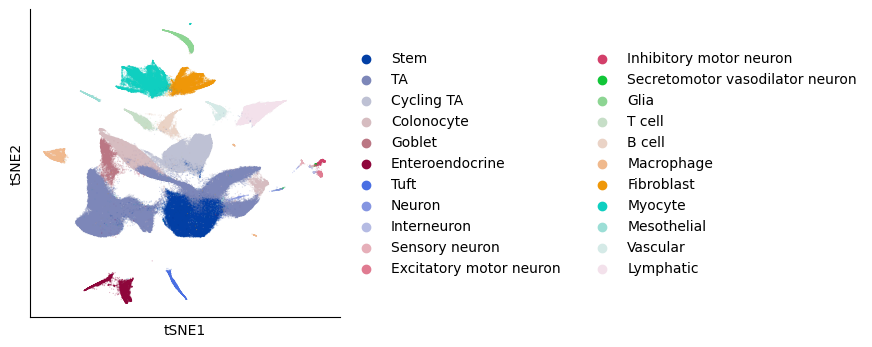

In [5]:
adata.obs['cell_type_rename'] = [capitalize_first_if_not_all_caps(i.replace('_', ' ')) for i in adata.obs['cell_type']]
adata.obs["cell_type_rename"] = adata.obs["cell_type_rename"].astype('category')

new_order = [
    # Stem / progenitors
    "Stem", "TA", "Cycling TA",
    # Epithelial lineages
    "Colonocyte", "Goblet", "Enteroendocrine", "Tuft",
    # Neuronal lineages
    "Neuron", "Interneuron", "Sensory neuron", "Excitatory motor neuron", "Inhibitory motor neuron", "Secretomotor vasodilator neuron",
    # Glia
    "Glia",
    # Immune cells
    "T cell", "B cell", "Macrophage",
    # Mesenchymal / stromal
    "Fibroblast", "Myocyte", "Mesothelial",
    # Vascular / lymphatic
    "Vascular", "Lymphatic",
]
adata.obs["cell_type_rename"] = adata.obs["cell_type_rename"].cat.reorder_categories(new_order)

plot_tsne(adata, 'cell_type_rename', size=3, alpha=0.3, outfile='../paper/supp/colon_celltypes.pdf')

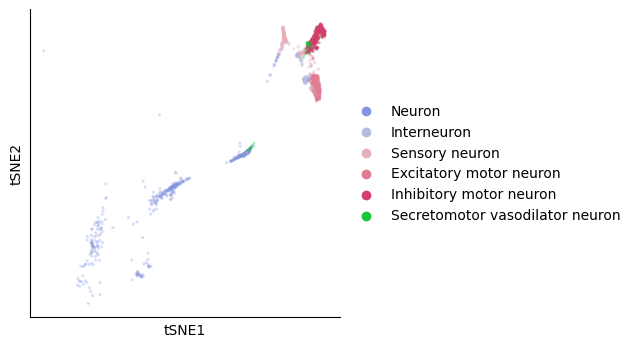

In [6]:
# plot
neuron_adata = adata[adata.obs['cell_type_rename'].str.contains('euron')]
plot_tsne(neuron_adata, 'cell_type_rename', alpha=0.3)

In [7]:
ct_df['discovery'] = ct_df['q'] <= 0.1
associated_cts = ct_df[ct_df['discovery']].index.values
ct_df[ct_df['discovery']]

,beta,se,z,p,q,sig_pct,n_mc,discovery
celltype,,,,,,,,
sensory_neuron,3.828148,1.568928,2.439977,0.007688,0.084563,0.833333,6,True
inhibitory_motor_neuron,6.463681,2.546885,2.537877,0.004746,0.084563,0.636364,11,True
secretomotor_vasodilator_neuron,5.363693,2.332957,2.299096,0.011766,0.086283,0.666667,3,True


In [8]:
# seismic
seismic_df = pd.read_csv(f'{indir}/seismic__trait-asd.csv', header=0, index_col=None)
seismic_df[seismic_df['q'] <= 0.1]

,celltype,beta,se,z,p,q
0,secretomotor_vasodilator_neuron,0.367021,0.125833,2.916736,0.001769,0.038909


In [9]:
# scdrs
scdrs_df = pd.read_csv('../results/2026-01-08__scDRS_asd_colon_downstream__ctcomb/asd.scdrs_group.cell_type', header=0, index_col=None, sep='\t')
scdrs_df['q'] = multipletests(scdrs_df['assoc_mcp'], method='fdr_bh')[1]
scdrs_df[scdrs_df['q'] <= 0.1]

,group,n_cell,n_ctrl,assoc_mcp,assoc_mcz,hetero_mcp,hetero_mcz,n_fdr_0.05,n_fdr_0.1,n_fdr_0.2,q


## check overall disease associated cell types

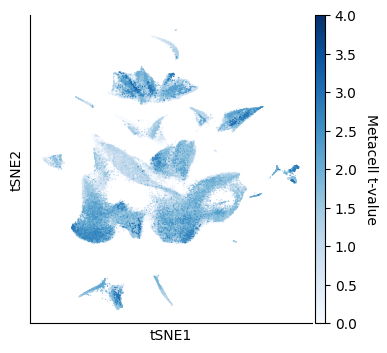

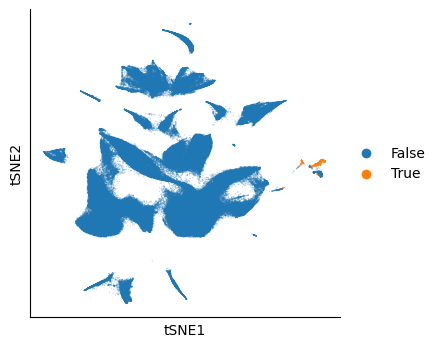

In [10]:
from matplotlib.colors import ListedColormap
adata.obs['ct_discovery'] = list(ct_df.loc[adata.obs['cell_type'], 'discovery'])
adata.obs['mc_t'] = [mc_df.loc[mc, 'z'] if mc in mc_df.index else 0.0 for mc in adata.obs['SEACell']]
plot_tsne(adata, 'mc_t', cmap='Blues', vmin=0.0, vmax=4.0, size=3, cbar='Metacell t-value', outfile='../paper/supp/colon_tval.pdf')
plot_tsne(adata, 'ct_discovery', size=3, alpha=0.3, outfile='../paper/supp/colon_bin.pdf')

In [11]:
ct_df.head(10)

,beta,se,z,p,q,sig_pct,n_mc,discovery
celltype,,,,,,,,
sensory_neuron,3.828148,1.568928,2.439977,0.007688,0.084563,0.833333,6,True
inhibitory_motor_neuron,6.463681,2.546885,2.537877,0.004746,0.084563,0.636364,11,True
secretomotor_vasodilator_neuron,5.363693,2.332957,2.299096,0.011766,0.086283,0.666667,3,True
excitatory_motor_neuron,4.078130,2.601402,1.567666,0.068093,0.299608,0.000000,6,False
Enteroendocrine,8.466603,3.934733,2.151761,0.065194,0.299608,0.000000,104,False
Lymphatic,13.337662,6.652499,2.004910,0.100198,0.314907,0.000000,189,False
Myocyte,9.710802,4.213836,2.304504,0.097520,0.314907,0.000000,274,False
interneuron,2.221037,1.687215,1.316392,0.143625,0.394969,0.000000,7,False
Fibroblast,6.892513,3.859189,1.786000,0.331008,0.809130,0.000000,209,False


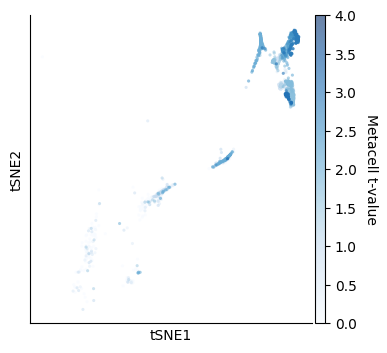

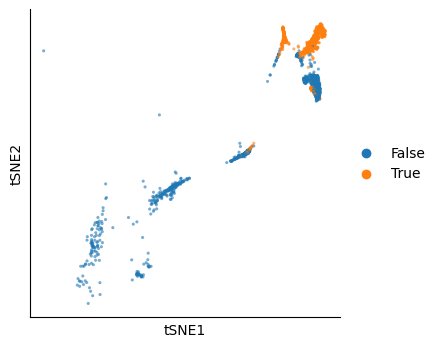

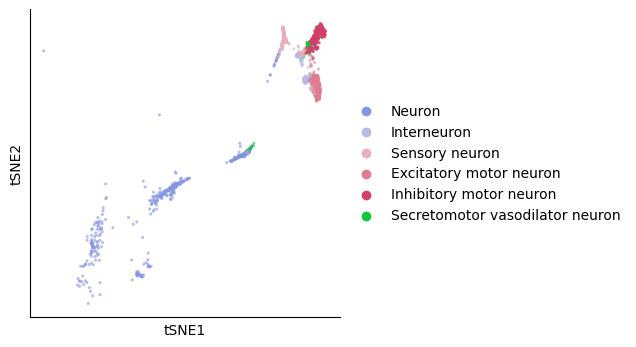

In [12]:
neuron_adata = adata[adata.obs['cell_type'].str.contains('euron')]
plot_tsne(neuron_adata, 'mc_t', cmap='Blues', vmin=0.0, vmax=4.0, alpha=0.6, cbar='Metacell t-value', outfile='../paper/figures/neuron_tval.pdf')
plot_tsne(neuron_adata, 'ct_discovery', alpha=0.6, outfile='../paper/figures/neuron_bin.pdf')
plot_tsne(neuron_adata, 'cell_type_rename', alpha=0.6, outfile='../paper/figures/neuron_ct.pdf')

## Neuronal association

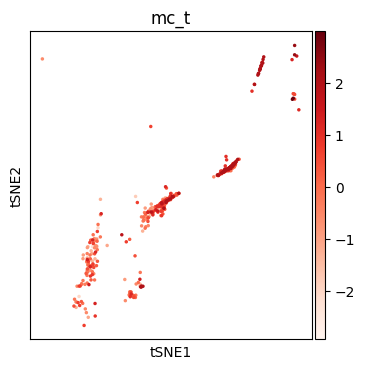

In [13]:
exp_ct = 'Neuron'
sub_adata = adata[(adata.obs['cell_type'] == exp_ct)]
sc.pl.tsne(
    sub_adata,
    color=['mc_t'],
    size=25,
    cmap='Reds'
)

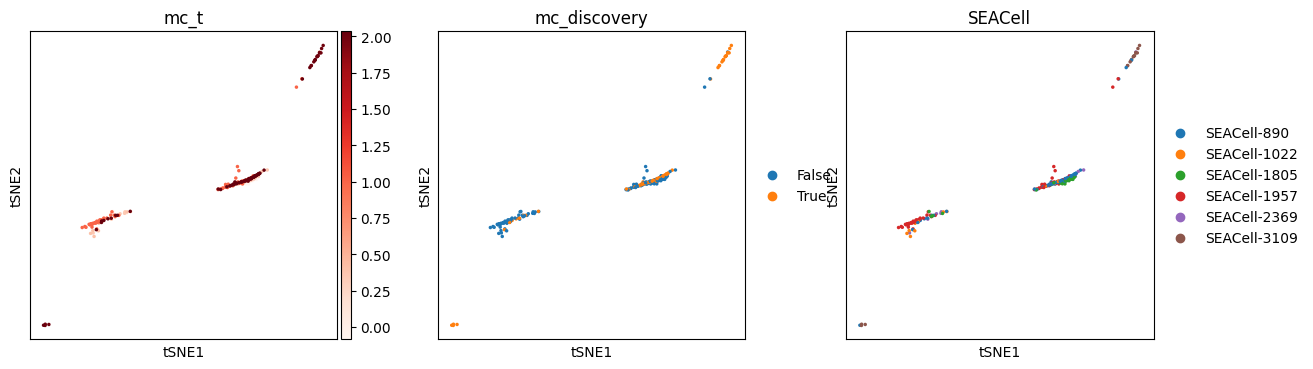

In [14]:
sub_adata = adata[
    (adata.obs['cell_type'] == exp_ct) &
    (adata.obs['SEACell'].isin(ct2meta[exp_ct]))
].copy()
sub_mc_df = mc_df[(mc_df.index.isin(ct2meta[exp_ct]))].copy()
sub_mc_df['q'] = multipletests(sub_mc_df['p'], method='fdr_bh')[1]
sub_mc_df['discovery'] = sub_mc_df['q'] <= 0.1
sub_adata.obs['mc_discovery'] = list(sub_mc_df.loc[sub_adata.obs['SEACell'], 'discovery'].astype(str))

sc.pl.tsne(
    sub_adata,
    color=['mc_t', 'mc_discovery', 'SEACell'],
    size=25,
    cmap='Reds'
)

## Sensory neuron

9 cell removed


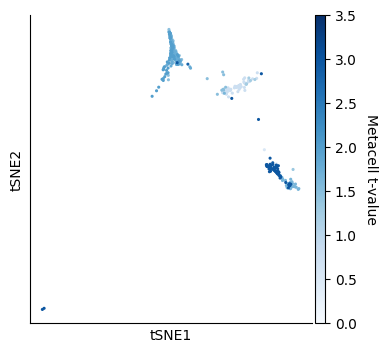

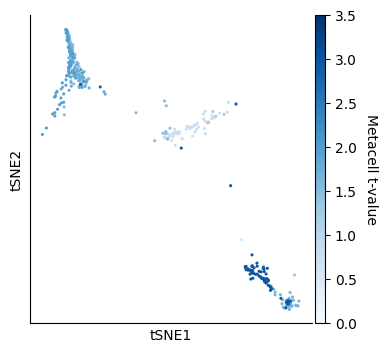

In [15]:
exp_ct = 'sensory_neuron'
sub_adata = adata[(adata.obs['cell_type'] == exp_ct)]
plot_tsne(sub_adata, 'mc_t', cmap='Blues', vmin=0.0, vmax=3.5, outfile='../paper/figures/SN_tval_full.pdf', cbar='Metacell t-value')
sub_adata = tsne_filter(sub_adata, 99.5)
plot_tsne(sub_adata, 'mc_t', cmap='Blues', vmin=0.0, vmax=3.5, outfile='../paper/figures/SN_tval.pdf', cbar='Metacell t-value')

6 cell removed


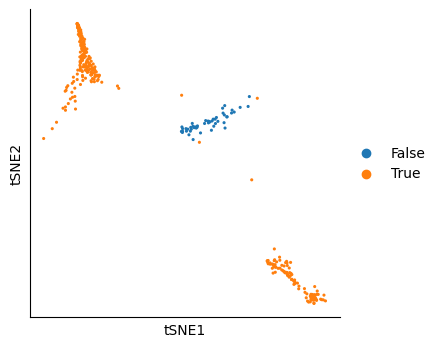

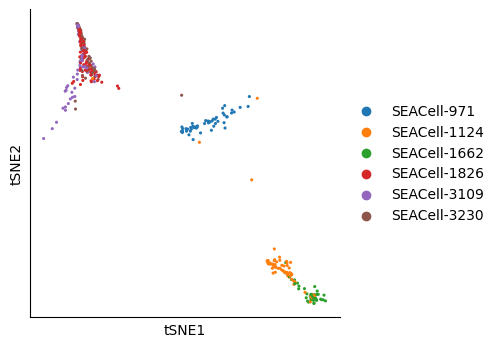

In [16]:
sub_adata = adata[
    (adata.obs['cell_type'] == exp_ct) &
    (adata.obs['SEACell'].isin(ct2meta[exp_ct]))
].copy()
sub_adata = tsne_filter(sub_adata, 99.5)
sub_mc_df = mc_df[(mc_df.index.isin(ct2meta[exp_ct]))].copy()
sub_mc_df['q'] = multipletests(sub_mc_df['p'], method='fdr_bh')[1]
sub_mc_df['discovery'] = sub_mc_df['q'] <= 0.1
sub_adata.obs['mc_discovery'] = list(sub_mc_df.loc[sub_adata.obs['SEACell'], 'discovery'].astype(str))

plot_tsne(sub_adata, 'mc_discovery', outfile='../paper/figures/SN_bin.pdf')
plot_tsne(sub_adata, 'SEACell', outfile='../paper/figures/SN_mc.pdf')

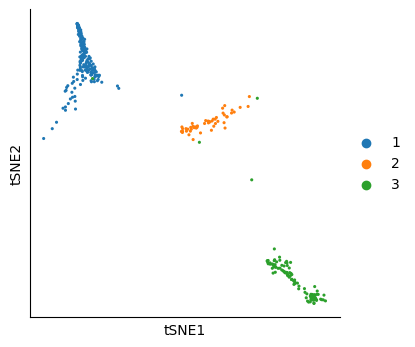

In [17]:
group_idx = []
for mc in sub_adata.obs['SEACell']:
    if mc in ['SEACell-3109', 'SEACell-1826', 'SEACell-3230']:
        group_idx.append('1')
    elif mc in ['SEACell-971']:
        group_idx.append('2')
    elif mc in ['SEACell-1124', 'SEACell-1662']:
        group_idx.append('3')
sub_adata.obs['cell_group'] = group_idx
plot_tsne(sub_adata, 'cell_group', outfile='../paper/figures/SN_cell_group.pdf')

In [18]:
sc.tl.rank_genes_groups(
    sub_adata,
    groupby="cell_group",   # column in adata.obs
)
c1_df = sc.get.rank_genes_groups_df(sub_adata, group='1')
c2_df = sc.get.rank_genes_groups_df(sub_adata, group='2')
c3_df = sc.get.rank_genes_groups_df(sub_adata, group='3')

/mnt/ufs18/rs-032/FishEvoDevoGeno/Hao/icepop/.venv/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [19]:
c1_df.head(20)['names'].values

array(['Dgkg', 'Zfp804a', 'Efr3a', 'Nmu', 'Mgat4c', 'Vgll3', 'Ano2',
       'Cntn5', 'Cntnap2', 'Ngfr', 'Cbln2', 'Gm21847', 'Cdh8', 'Slc35d3',
       'Cdh6', 'Pcdh9', 'Kcnt2', 'Spock3', 'Htr3b', 'Htr3a'], dtype=object)

In [20]:
c2_df.head(20)['names'].values

array(['Ntng1', 'Rarb', 'Fam155a', 'Slc44a5', 'Frmpd4', 'Gng2', 'Cd24a',
       'Etv1', 'Kcnd2', 'Pitpnc1', 'Grid1', 'Auts2', 'Pde4b', 'Nav3',
       'Nsg1', 'Kcnc2', 'Nefl', 'Arhgap28', 'Dlc1', 'Gpc6'], dtype=object)

In [21]:
c3_df.head(20)['names'].values

array(['Pcdh15', 'Lrp1b', 'Nrg3', 'Trpm3', 'Gria2', 'Fam19a2', 'Dlgap2',
       'Gfra2', 'Eml6', 'Galntl6', 'Kcnma1', 'Nlgn1', 'Mdga2', 'Bnc2',
       'Slit3', 'Plcxd3', 'Chsy3', 'Syn2', 'Sema6d', 'Pde4b'],
      dtype=object)

In [22]:
miss_exp = sc.read('../data/sc_data/asd_colon_missed_exp.h5ad')
sub_adata.obs['Chat'] = miss_exp[sub_adata.obs_names, 'Chat'].X.toarray().ravel()

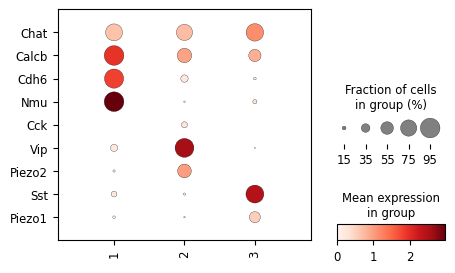

In [23]:
genes = [
   "Chat", "Calcb", "Cdh6", "Nmu", "Cck", "Vip", "Piezo2", "Sst", "Piezo1"
]
dp = sc.pl.dotplot(
    sub_adata,
    var_names=genes,
    groupby="cell_group",
    figsize=(5, 3),   # width, height in inches
    dot_min=0.05,
    dot_max=0.95,
    swap_axes=True,
    show=False,
    return_fig=True
)
dp.savefig("../paper/figures/SN_marker.pdf")

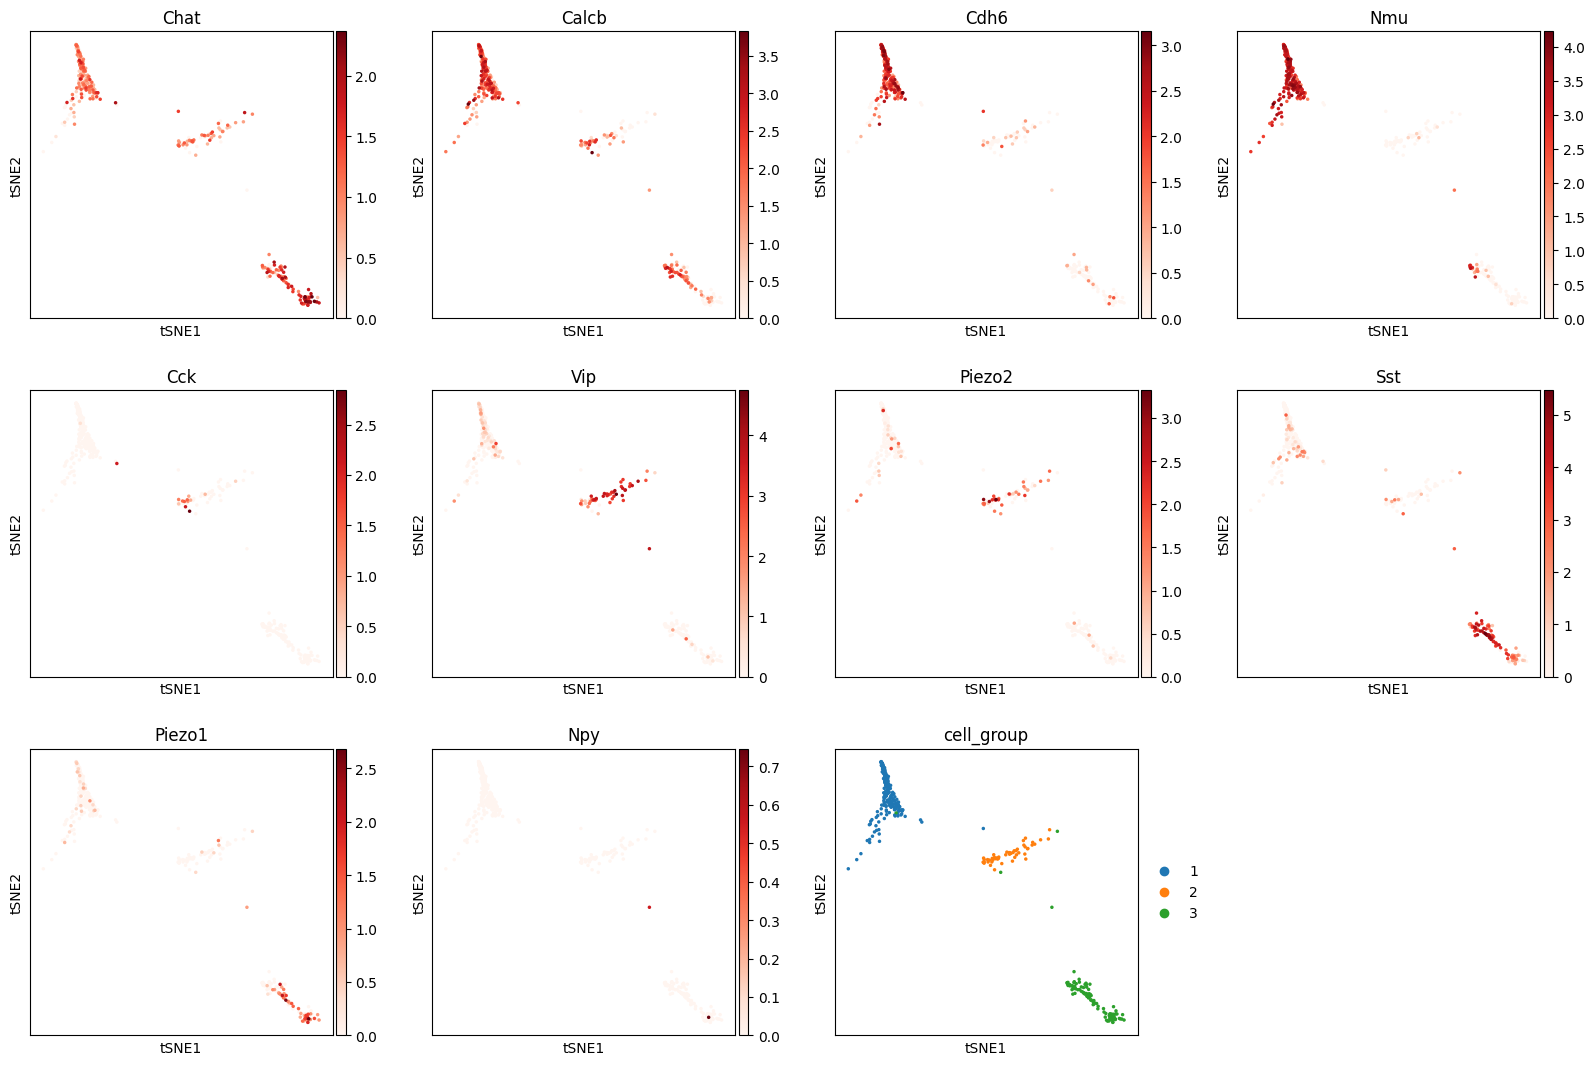

In [24]:
sc.pl.tsne(
    sub_adata,
    color=["Chat", "Calcb", "Cdh6", "Nmu", "Cck", "Vip", "Piezo2", "Sst", "Piezo1", "Npy", 'cell_group'],
    size=25,
    cmap='Reds'
)

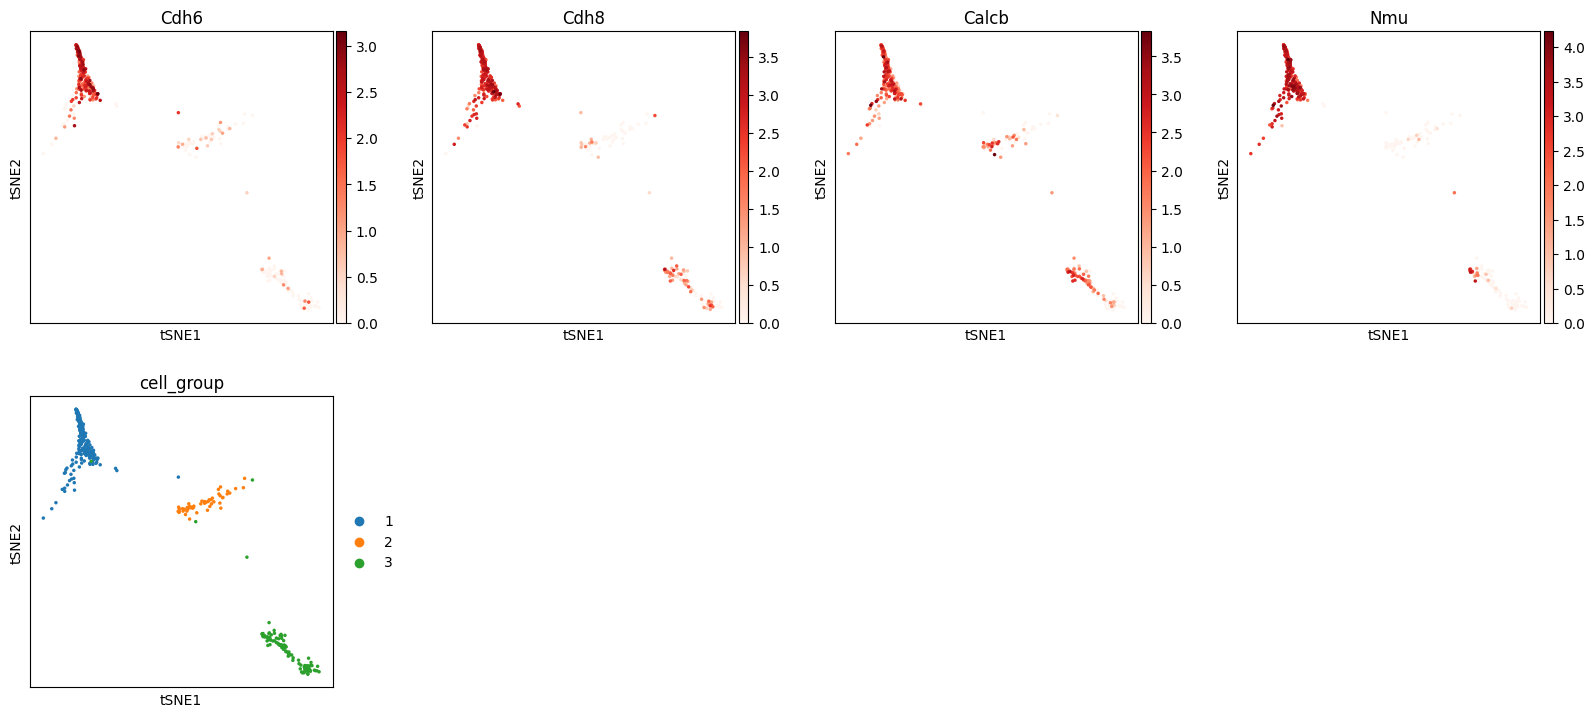

In [25]:
# Cdh6+ sensory neuron, related to colon mobility 10.7554/eLife.101043.2
# I_H in sensory neuron
#    ↓
# Intrinsic rhythmic firing
#    ↓
# Activation of ENS interneurons
#    ↓
# Recruitment of motor neurons
#    ↓
# Colonic motor complex (CMC)
sc.pl.tsne(
    sub_adata,
    color=['Cdh6', 'Cdh8', 'Calcb', 'Nmu', 'cell_group'],
    size=25,
    cmap='Reds'
)

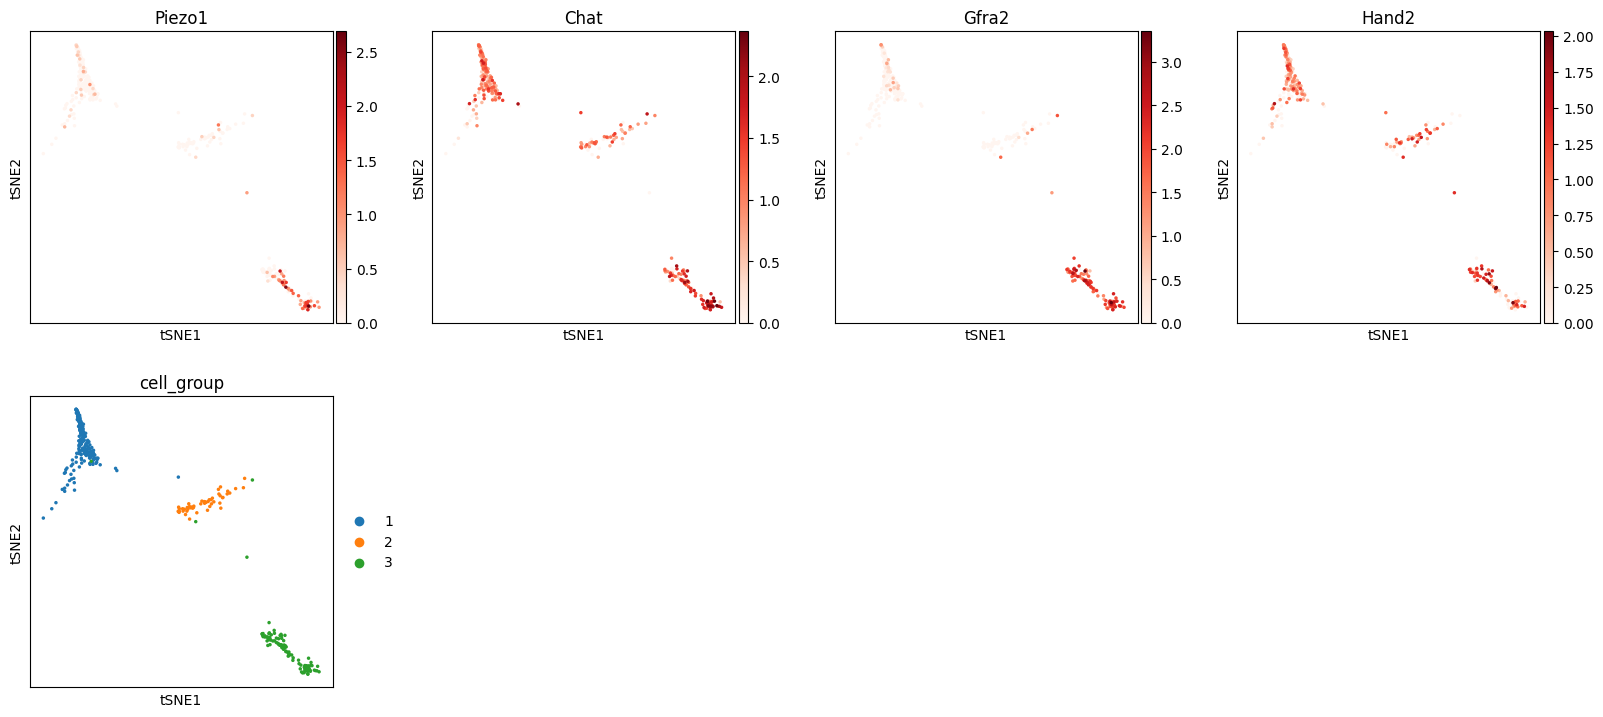

In [26]:
# Piezo1+ mechanosensor expression in cholinergic enteric neurons
# Additionally, Piezo1 deficiency in cholinergic enteric neurons abolishes exercise-induced acceleration of GI motility.
# loss of Piezo1 in cholinergic neurons also resulted in slower total
# DOI: 10.1016/j.cell.2025.02.031
# Gfra2 is related to Hirschsprung disease 10.1007/s004390100506

sc.pl.tsne(
    sub_adata,
    color=['Piezo1', 'Chat', 'Gfra2', 'Hand2', 'cell_group'],
    size=25,
    cmap='Reds', 
)

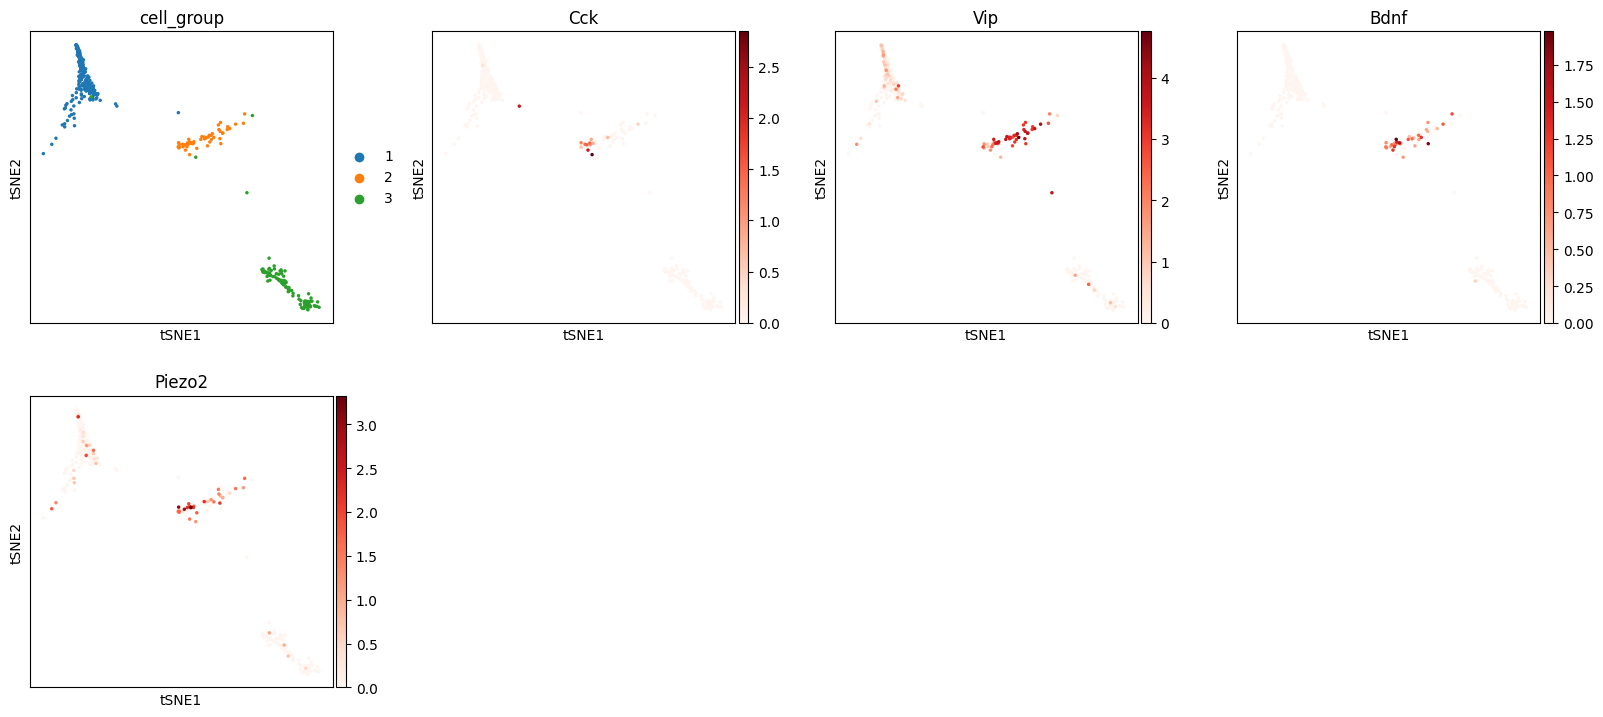

In [27]:
# this group express markers of intestinofugal neuron (carrying signals out of the gut wall to the sympathetic ganglia)
# 10.1016/j.pneurobio.2003.12.004
# 10.1016/j.cell.2020.08.003
sc.pl.tsne(
    sub_adata,
    color=['cell_group', 'Cck', 'Vip', 'Bdnf', 'Piezo2'],
    size=25,
    cmap='Reds'
)

## ASD genes that have direct effect on sensory neuron
### Disruption of sensory processing in sensory neuron
### Cntnap2
- 10.1101/2023.04.17.537221
    - ASD-related synaptic cell-adhesion molecule important for sensory processing.
- 10.1016/j.biopsych.2023.03.014 (but described in Cortical Excitatory Neuron)
    - CNTNAP2 encodes CASPR2, a single-pass transmembrane protein that belongs to the neurexin family of cell adhesion molecules. These proteins have a variety of functions in developing neurons, including connecting presynaptic and postsynaptic neurons, and mediating signaling across the synapse.
    - Live imaging of excitatory neuronal growth showed that loss of CNTNAP2 reduced neurite branching and overall neuronal complexity.
### Disruption of neuronal progenitor migration lead to reduced sensory neuron population
### Cdh8, Cdh2
- 10.1038/s41467-025-57342-3
### Disruption in serotonin receptor in sensory neuron
### Htr3a
- 10.1007/s10048-009-0171-7

## Comparison strategies
- We expect high risk ASD genes are more enriched in sensory neuron specific genes than IFN

Synaptic "Wiring" Errors: Many ASD-linked genes (like NLGN3, SHANK3, and CNTNAP2) encode proteins that act as the "glue" or "scaffolding" for synapses. Because IPANs must constantly communicate with local interneurons to coordinate movement, mutations in these proteins lead to leaky or noisy synapses

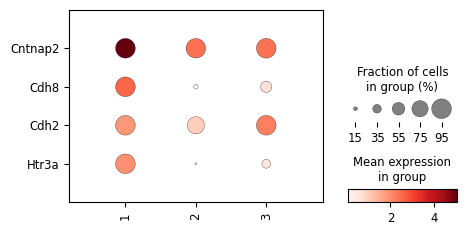

In [28]:
genes = [
   "Cntnap2", "Cdh8", "Cdh2", "Htr3a"
]
dp = sc.pl.dotplot(
    sub_adata,
    var_names=genes,
    groupby="cell_group",
    figsize=(5, 2.5),   # width, height in inches
    dot_min=0.05,
    dot_max=0.95,
    swap_axes=True,
    show=False,
    return_fig=True
)
dp.savefig("../paper/figures/SN_ASD.pdf", bbox_inches="tight")

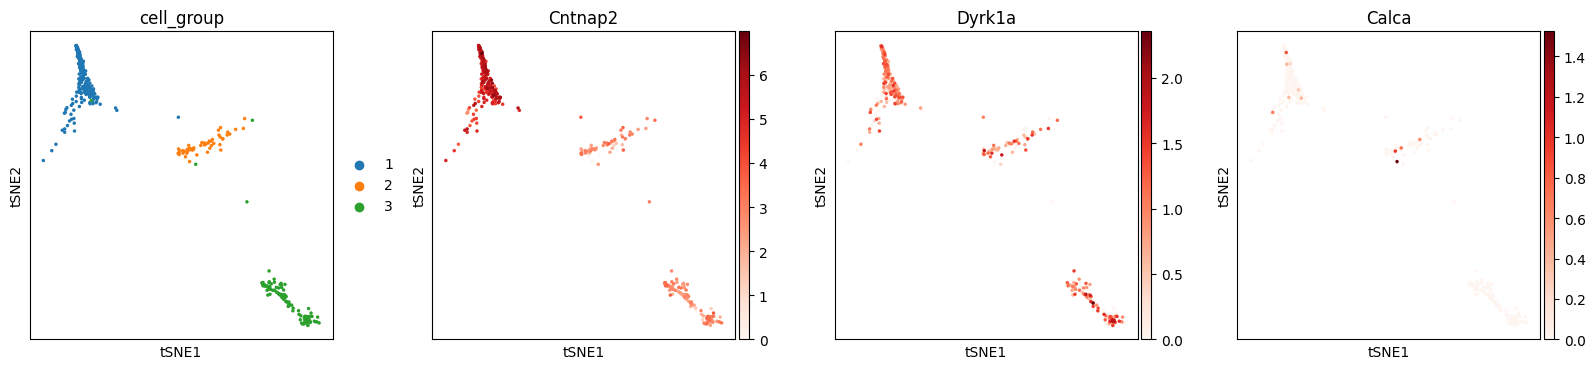

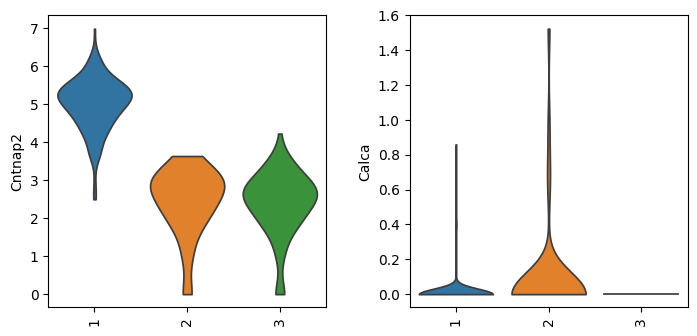

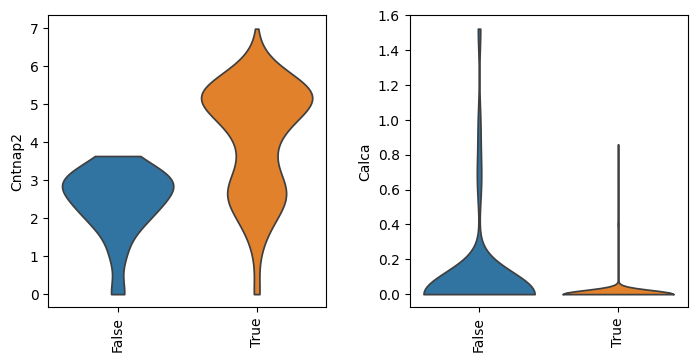

In [29]:
# Cntnap2 10.3389/fnins.2023.1287057 Loss of ASD-related molecule Cntnap2 affects colonic motility in mice
sc.pl.tsne(
    sub_adata,
    color=['cell_group', 'Cntnap2', 'Dyrk1a', 'Calca'],
    size=25,
    cmap='Reds'
)

genes = ["Cntnap2", "Calca"]
sc.pl.violin(
    sub_adata,
    keys=genes,
    groupby="cell_group",
    rotation=90,
    stripplot=False,   # cleaner
    jitter=False,
    density_norm="width"
)
sc.pl.violin(
    sub_adata,
    keys=genes,
    groupby="mc_discovery",
    rotation=90,
    stripplot=False,   # cleaner
    jitter=False,
    density_norm="width"
)

Serotonin ($5\text{-HT}$) Overload: IPANs are the primary sensors for serotonin released by the gut lining. In ASD, there is often a "high serotonin" state (hyperserotonemia).2 This chronically overstimulates the sensory neurons, leading to a state of sensory "exhaustion" or hypersensitivity.

10.3390/app13052970

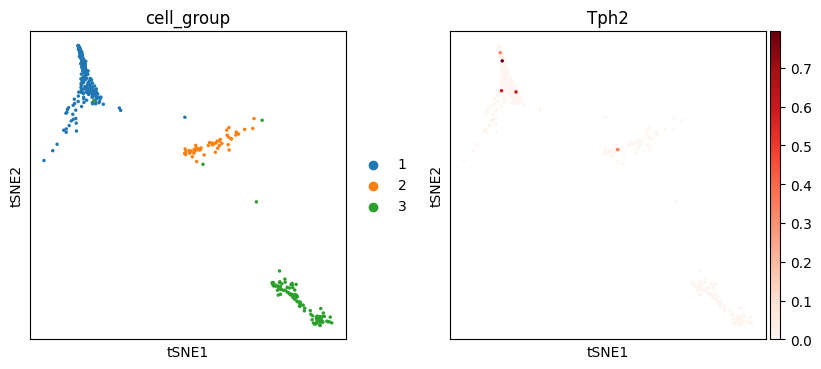

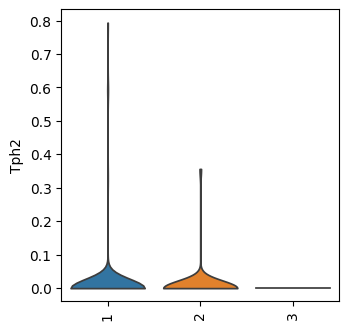

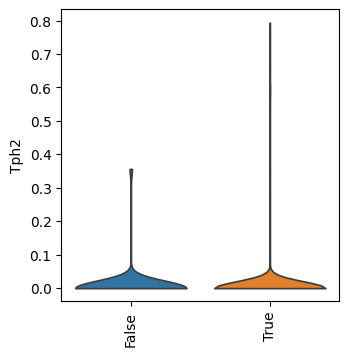

In [30]:
sc.pl.tsne(
    sub_adata,
    color=['cell_group', 'Tph2'],
    size=25,
    cmap='Reds'
)

genes = ["Tph2"]
sc.pl.violin(
    sub_adata,
    keys=genes,
    groupby="cell_group",
    rotation=90,
    stripplot=False,   # cleaner
    jitter=False,
    density_norm="width"
)
sc.pl.violin(
    sub_adata,
    keys=genes,
    groupby="mc_discovery",
    rotation=90,
    stripplot=False,   # cleaner
    jitter=False,
    density_norm="width"
)

Developmental Migration: Recent research (2024/2025) shows that some ASD gene variants (like DYRK1A) actually slow down the migration of neuron progenitors during embryonic development, meaning the gut ends up with a lower density of functional sensory neurons

10.1038/s41467-025-57342-3

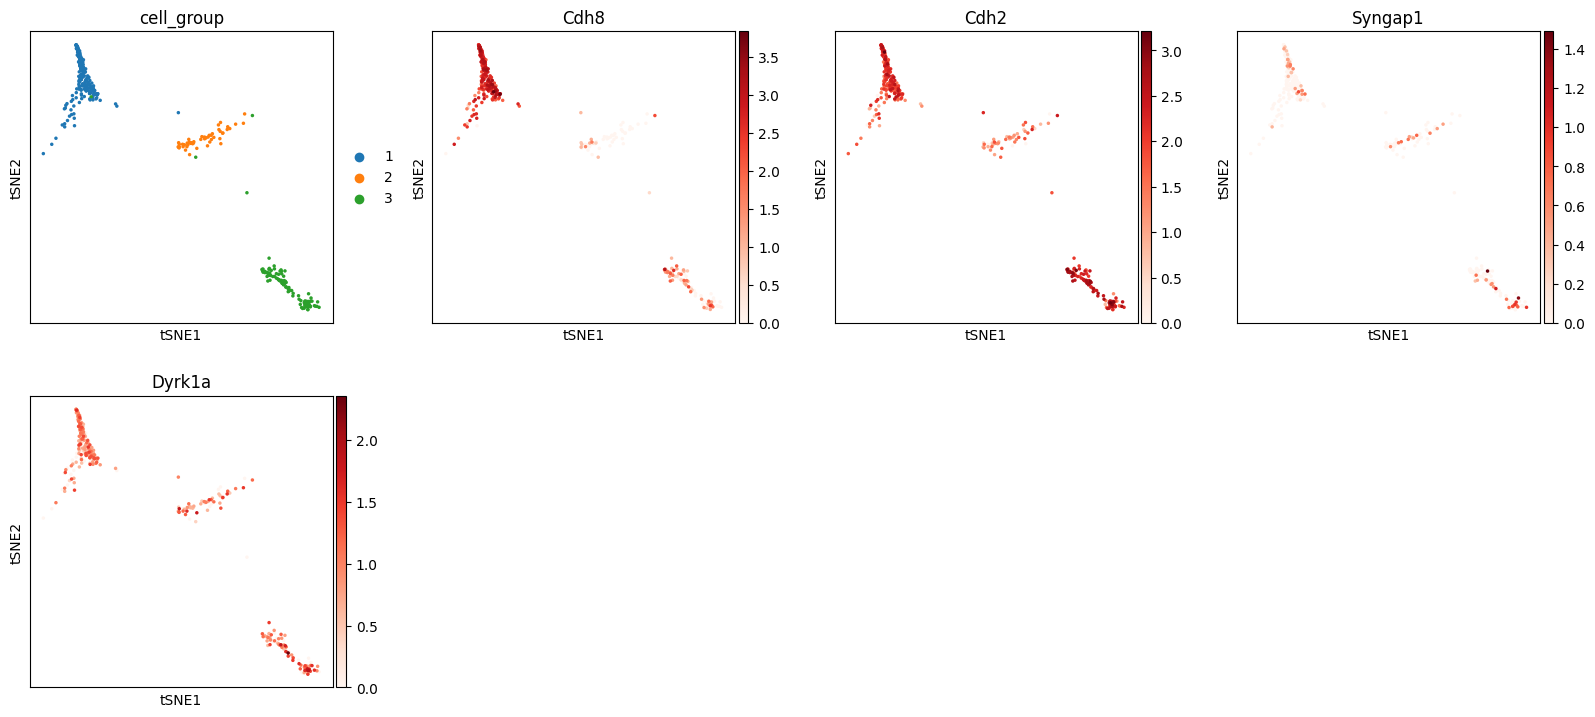

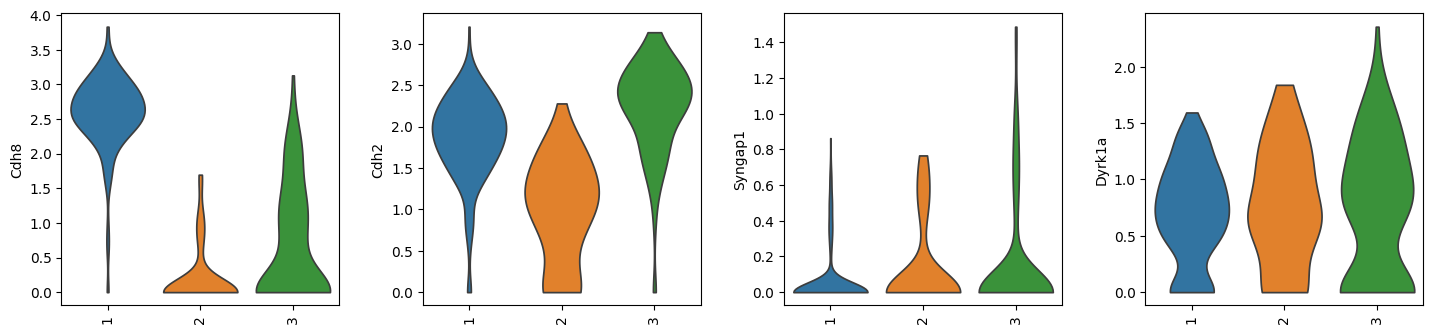

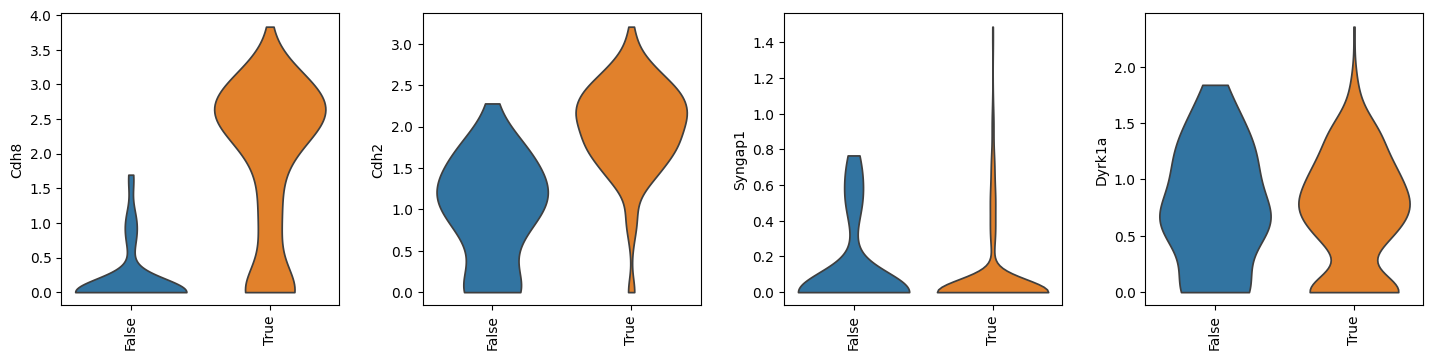

In [31]:
sc.pl.tsne(
    sub_adata,
    color=['cell_group', 'Cdh8', 'Cdh2', 'Syngap1', 'Dyrk1a'],
    size=25,
    cmap='Reds'
)

genes = ["Cdh8", "Cdh2", "Syngap1", "Dyrk1a"]
sc.pl.violin(
    sub_adata,
    keys=genes,
    groupby="cell_group",
    rotation=90,
    stripplot=False,   # cleaner
    jitter=False,
    density_norm="width"
)
sc.pl.violin(
    sub_adata,
    keys=genes,
    groupby="mc_discovery",
    rotation=90,
    stripplot=False,   # cleaner
    jitter=False,
    density_norm="width"
)

## check influ genes in SFARI genes

In [32]:
sf_df = pd.read_csv('../data/asd/SFARI-Gene_genes_01-13-2025release_03-27-2025export.csv', header=0, index_col=None)
mg = mygene.MyGeneInfo()
results = mg.querymany(sf_df['ensembl-id'], scopes='ensemblgene', fields='entrezgene', species='human')
ensembl2entrez = {r['query']: r.get('entrezgene', None) for r in results}
sf_df['entrez'] = [ensembl2entrez[ens] if ens in ensembl2entrez else None for ens in sf_df['ensembl-id']]
sf_df = sf_df[~pd.isna(sf_df['entrez'])].copy()
hi_conf_genes = sf_df[sf_df['gene-score'] <= 2.0]['entrez'].values

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
11 input query terms found no hit:	['nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan']


In [33]:
hi_conf_genes.size

935

In [34]:
# cell group to mc
tmp = {
    "1": ['SEACell-3109', 'SEACell-1826', 'SEACell-3230'],
    "2": ['SEACell-971'],
    "3": ['SEACell-1124', 'SEACell-1662']
}
cell_group_map = {}
for group, mcs in tmp.items():
    for i in mcs:
        cell_group_map[i] = group

# discovery to mc
tmp = {
    "True": ['SEACell-3109', 'SEACell-1826', 'SEACell-3230', 'SEACell-1124', 'SEACell-1662'],
    "False": ['SEACell-971'],
}
cell_group_asso_map = {}
for group, mcs in tmp.items():
    for i in mcs:
        cell_group_asso_map[i] = group

In [35]:
# convert spec score across species
score_converter = CrossSpeciesScoreConverter(adata, sp='10090')
score_converter.generate_cross_sp_matrix()
mc_spec_score = score_converter.convert_score_across_species(adata.uns['spec_score'], normed=False)

sn_mcs = list(cell_group_map.keys())
non_zero_idx = np.argwhere((mc_spec_score.loc[sn_mcs, :] != 0).sum(0) > 0).ravel()
mc_spec_score = mc_spec_score.loc[sn_mcs].iloc[:, non_zero_idx]

2026-01-29 00:18:44,469 - icepop - INFO - Convert exp specificity score across species through homology


In [36]:
asd_df = pd.read_csv('../data/gwas/zstat/asd.csv', header=0, index_col=0)
asd_df.index = asd_df.index.astype(str)
shared_genes = mc_spec_score.columns.intersection(asd_df.index)
X = mc_spec_score.loc[:, shared_genes].values
y = asd_df.loc[shared_genes, 'ZSTAT'].values

In [37]:
from scipy.stats import norm
def linear_reg(X, y, eps=1e-12):
    # Replace NaNs
    X = np.where(np.isnan(X), 0.0, X)
    y = np.where(np.isnan(y), 0.0, y)

    # Ensure 2D
    if X.ndim == 1:
        X = X[None, :]   # (1, n_gene)

    k, n = X.shape

    # --- Mean-center if intercept implied
    y = y - np.mean(y)
    X = X - np.mean(X, axis=1, keepdims=True)

    # --- Regression core
    xy = X @ y                        # shape (k,)
    xx = np.sum(X**2, axis=1) + eps   # shape (k,)
    beta = xy / xx                    # shape (k,)

    # --- Residuals
    resid = y[None, :] - beta[:, None] * X
    rss = np.sum(resid**2, axis=1)
    s2 = rss / (n - 1)
    se = np.sqrt(s2 / (xx + eps))

    # --- t-statistics and one-sided p-values
    t = beta / (se + eps)
    pval = norm.sf(t)

    # --- DFBETAS (influence of each gene)
    h = (X**2) / (xx[:, None] + eps)
    dfb = ((X / (xx[:, None] + eps)) * resid) / (1 - h + eps)

    return beta, se, pval, dfb
beta, se, pval, dfb = linear_reg(X, y, eps=1e-12)

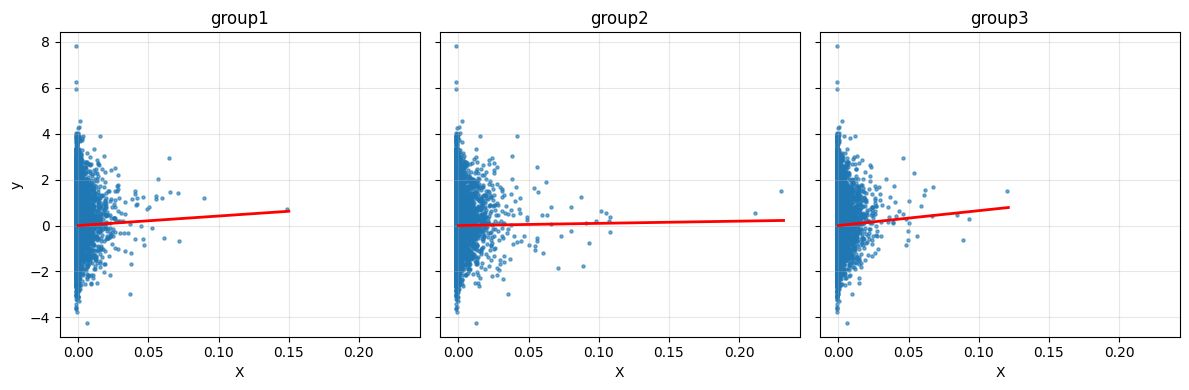

In [38]:
groups = {
    "group1": 0,
    "group2": 3,
    "group3": 4,
}

dfb_df = pd.DataFrame(dfb, index=mc_spec_score.index, columns=shared_genes)

influ_genes_map = {}
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True,  sharex=True)
for ax, (name, i) in zip(axes, groups.items()):
    # scatter
    x = X[i]
    coef = beta[i]
    x_mean = x - x.mean()
    y_mean = y - x.mean()
    
    ax.scatter(x_mean, y_mean, s=5, alpha=0.6)

    # fit line y = a*x + b
    x_fit = np.linspace(x.min(), x.max(), 200)
    y_fit = coef * x_fit

    ax.plot(x_fit, y_fit, linewidth=2, c='red')

    # inf_genes = dfb_df.iloc[i, :].sort_values(ascending=False).head(100).index.values
    # g_idx = dfb_df.columns.get_indexer(inf_genes)
    # ax.scatter(x_mean[g_idx], y_mean[g_idx], s=5, alpha=0.6, color='orange')

    ax.set_title(name)
    ax.set_xlabel("X")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("y")
plt.tight_layout()
plt.show()

In [39]:
def precision_at_k(df, sfari_hc, k=100):
    sfari_hc = set(sfari_hc)

    precisions = []
    for idx, row in df.iterrows():
        topk_genes = row.sort_values(ascending=False).index[:k]
        hits = sum(g in sfari_hc for g in topk_genes)
        precisions.append(hits / k)

    return pd.Series(precisions, index=df.index, name=f'precision@{k}')

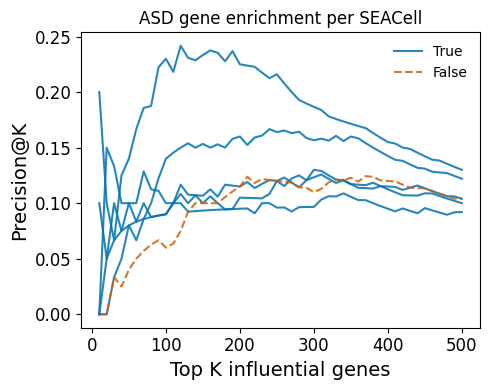

In [40]:
Ks = np.arange(10, 501, 10)

# Color-blind friendly (Okabe–Ito palette)
group_colors = {
    "True":  "#0072B2",  # blue
    "False": "#D55E00",  # orange
}

# Line styles
group_linestyles = {
    "True":  "-",        # solid
    "False": "--",       # dashed
}

plt.figure(figsize=(5, 4))

seen_groups = set()

for seacell in dfb_df.index:
    group = cell_group_asso_map[seacell]

    precisions = [
        precision_at_k(dfb_df.loc[[seacell]], hi_conf_genes, k=k).iloc[0]
        for k in Ks
    ]

    label = group if group not in seen_groups else None
    seen_groups.add(group)

    plt.plot(
        Ks,
        precisions,
        color=group_colors[group],
        linestyle=group_linestyles[group],
        lw=1.5,
        alpha=0.85,
        label=label
    )

plt.xlabel("Top K influential genes", fontsize=14)
plt.ylabel("Precision@K", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("ASD gene enrichment per SEACell")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig('../paper/figures/SFARI_enrich_bin.pdf')

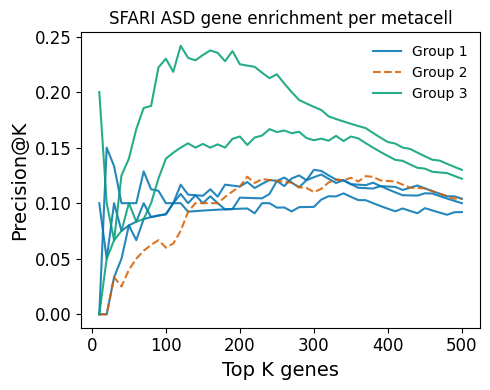

In [41]:
Ks = np.arange(10, 501, 10)

# Color-blind friendly colors
group_colors = {
    "1": "#0072B2",  # blue
    "2": "#D55E00",  # orange
    "3": "#009E73",  # green
}

# Line styles per group
group_linestyles = {
    "1": "-",
    "2": "--",
    "3": "-",
}

plt.figure(figsize=(5, 4))

seen_groups = set()

for seacell in dfb_df.index:
    group = cell_group_map[seacell]

    precisions = [
        precision_at_k(dfb_df.loc[[seacell]], hi_conf_genes, k=k).iloc[0]
        for k in Ks
    ]

    label = f"Group {group}" if group not in seen_groups else None
    seen_groups.add(group)

    plt.plot(
        Ks,
        precisions,
        color=group_colors[group],
        linestyle=group_linestyles[group],
        lw=1.5,
        alpha=0.85,
        label=label
    )

plt.xlabel("Top K genes", fontsize=14)
plt.ylabel("Precision@K", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("SFARI ASD gene enrichment per metacell")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig('../paper/figures/SFARI_enrich_cellgroup.pdf')

## inhibitory motor neuron

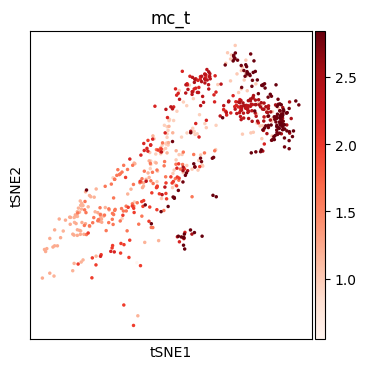

In [42]:
exp_ct = 'inhibitory_motor_neuron'
sub_adata = adata[(adata.obs['cell_type'] == exp_ct)]
sc.pl.tsne(
    sub_adata,
    color=['mc_t'],
    size=25,
    cmap='Reds'
)

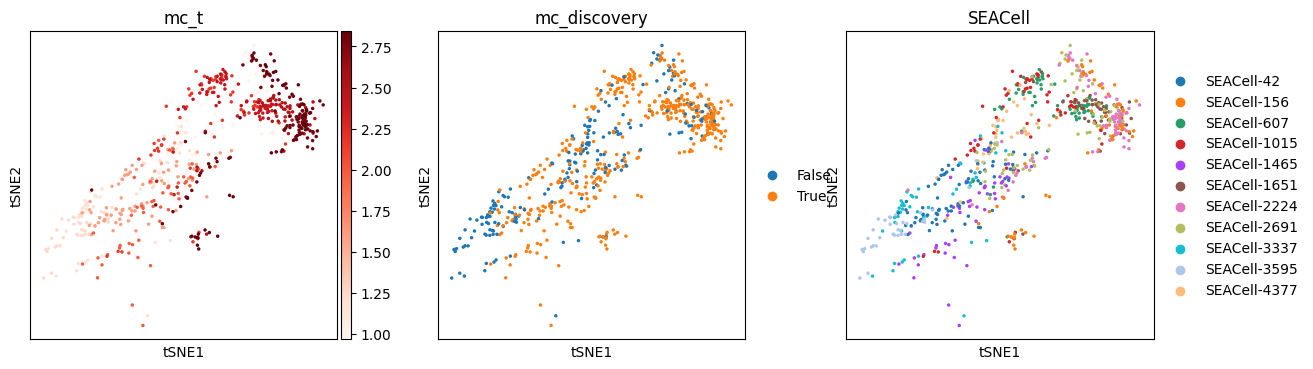

In [43]:
sub_adata = adata[
    (adata.obs['cell_type'] == exp_ct) &
    (adata.obs['SEACell'].isin(ct2meta[exp_ct]))
].copy()
sub_mc_df = mc_df[(mc_df.index.isin(ct2meta[exp_ct]))].copy()
sub_mc_df['q'] = multipletests(sub_mc_df['p'], method='fdr_bh')[1]
sub_mc_df['discovery'] = sub_mc_df['q'] <= 0.1
sub_adata.obs['mc_discovery'] = list(sub_mc_df.loc[sub_adata.obs['SEACell'], 'discovery'].astype(str))

sc.pl.tsne(
    sub_adata,
    color=['mc_t', 'mc_discovery', 'SEACell'],
    size=25,
    cmap='Reds'
)

## secretomotor vasodilator neuron

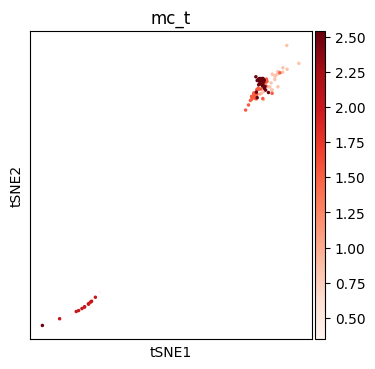

In [44]:
exp_ct = 'secretomotor_vasodilator_neuron'
sub_adata = adata[(adata.obs['cell_type'] == exp_ct)]
sc.pl.tsne(
    sub_adata,
    color=['mc_t'],
    size=25,
    cmap='Reds'
)

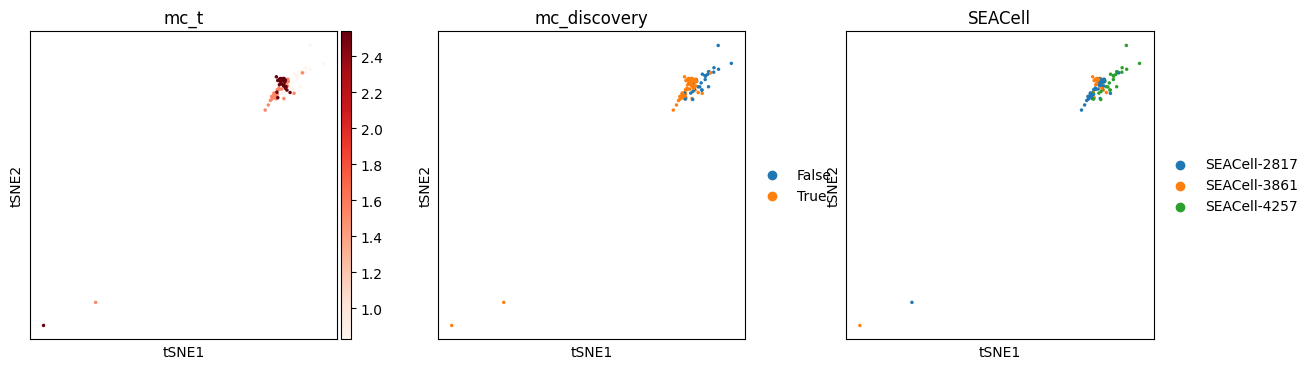

In [45]:
sub_adata = adata[
    (adata.obs['cell_type'] == exp_ct) &
    (adata.obs['SEACell'].isin(ct2meta[exp_ct]))
].copy()
sub_mc_df = mc_df[(mc_df.index.isin(ct2meta[exp_ct]))].copy()
sub_mc_df['q'] = multipletests(sub_mc_df['p'], method='fdr_bh')[1]
sub_mc_df['discovery'] = sub_mc_df['q'] <= 0.1
sub_adata.obs['mc_discovery'] = list(sub_mc_df.loc[sub_adata.obs['SEACell'], 'discovery'].astype(str))

sc.pl.tsne(
    sub_adata,
    color=['mc_t', 'mc_discovery', 'SEACell'],
    size=25,
    cmap='Reds'
)